In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sample-submission/sample_submission.csv
/kaggle/input/exploratory-accelerometer-data-analysis/test_series_preprocessed.parquet
/kaggle/input/exploratory-accelerometer-data-analysis/__results__.html
/kaggle/input/exploratory-accelerometer-data-analysis/__notebook__.ipynb
/kaggle/input/exploratory-accelerometer-data-analysis/train_series_preprocessed.parquet
/kaggle/input/exploratory-accelerometer-data-analysis/__output__.json
/kaggle/input/exploratory-accelerometer-data-analysis/custom.css
/kaggle/input/exploratory-accelerometer-data-analysis/__results___files/__results___55_3.png
/kaggle/input/exploratory-accelerometer-data-analysis/__results___files/__results___55_1.png
/kaggle/input/exploratory-accelerometer-data-analysis/__results___files/__results___56_2.png
/kaggle/input/exploratory-accelerometer-data-analysis/__results___files/__results___39_0.png
/kaggle/input/exploratory-accelerometer-data-analysis/__results___files/__results___55_4.png
/kaggle/input/exploratory-a

In [2]:
# Import libraries to use
import polars as pl
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
%%time
train_series = (pl.scan_parquet('/kaggle/input/exploratory-accelerometer-data-analysis/train_series_preprocessed.parquet')
                .with_columns(
                    (
                        (pl.col("timestamp").dt.hour().alias("hour")),
                    )
                )
                .collect()
                .to_pandas()
                .drop(columns='timestamp')
               )

CPU times: user 23.1 s, sys: 10.9 s, total: 34 s
Wall time: 31.4 s


In [4]:
train_series.head()

,series_id,step,anglez,enmo,event,hour
0,fe90110788d2,0.0,-27.707001,0.0298,wakeup,17
1,fe90110788d2,1.0,-33.867500,0.0488,wakeup,17
2,fe90110788d2,2.0,-15.475000,0.1077,wakeup,17
3,fe90110788d2,3.0,-73.656197,0.0530,wakeup,17
4,fe90110788d2,4.0,-53.152901,0.0601,wakeup,17


In [5]:
%%time
test_series = (pl.scan_parquet('/kaggle/input/exploratory-accelerometer-data-analysis/test_series_preprocessed.parquet')
                .with_columns(
                    (
                        (pl.col("timestamp").dt.hour().alias("hour")),
                    )
                )
                .collect()
                .to_pandas()
                .drop(columns='timestamp')
               )

CPU times: user 3.89 ms, sys: 1.42 ms, total: 5.31 ms
Wall time: 12.7 ms


In [6]:
test_series.head()

,series_id,step,anglez,enmo,hour
0,038441c925bb,0.0,2.6367,0.0217,15
1,038441c925bb,1.0,2.6368,0.0215,15
2,038441c925bb,2.0,2.6370,0.0216,15
3,038441c925bb,3.0,2.6368,0.0213,15
4,038441c925bb,4.0,2.6368,0.0215,15


In [7]:
#Check for any missing values
train_series.isna().sum()

series_id    0
step         0
anglez       0
enmo         0
event        0
hour         0
dtype: int64

### Class Balance
Compute the value counts for the "event" column. We calculate the relative frequencies of the classes, not the raw count (so we set the normalize argument to True).

In [8]:
train_series['event'].value_counts(normalize=True)

event
wakeup    0.624921
onset     0.375079
Name: proportion, dtype: float64

As a rule of thumb, if a two-class dataset has a difference of greater than 65% to 35%, then it should be looked at as a dataset with class imbalance (Source: medium.com). Here difference between wakeup and onset classes is about 24%. We consider this a balanced dataset.

### Split Data
Create a feature matrix X and target vector y. Target is "event".


In [9]:
features = ['anglez', 'enmo', 'hour']
encode_map = {'wakeup':0, 'onset':1}

X = train_series[features]
y = train_series.event.map(encode_map)

Divide the data (X and y) into training and test sets using a randomized train-test split. The validation set should be 10% of the total data. And we set a random_state for reproducibility.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

## Build Model

### Baseline
We need to establish the baseline for our model. Since this is a classification problem, we will use accuracy score.


In [11]:
#Calculate the baseline accuracy score for your model.
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 4))

Baseline Accuracy: 0.6249


What does this information tell us? If we always predicted sleep onset or wake, our predictions would be about 62% accurate. It also tells us that our model needs to have an accuracy above 62% in order to be useful.

In [12]:
model = make_pipeline(
    DecisionTreeClassifier(random_state=42)
)
model.fit(X_train, y_train)

Pipeline(steps=[('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

In [13]:
# Determine model accuracy
acc_train = model.score(X_train, y_train)
acc_test = model.score(X_test, y_test)

print("Training Accuracy:", round(acc_train, 4))
print("Test Accuracy:", round(acc_test, 4))

Training Accuracy: 0.9791
Test Accuracy: 0.9285


We beat the baseline by far! We want our test performance to be about the same as our training performance, but it's OK if it's not quite as good. Looks good here!!

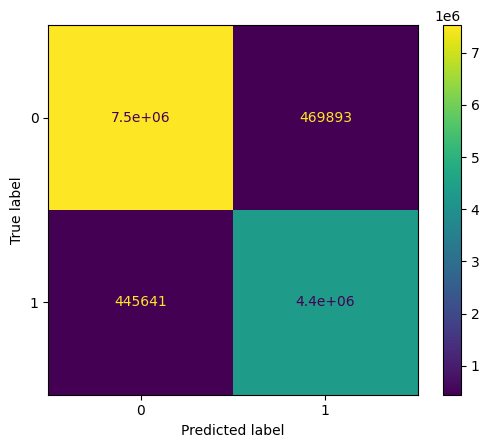

In [14]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

#Plot a confusion matrix that shows how the model performs on the test set.
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test);

The accuracy score will be amazing, but it won't tell us what we really need to know. Instead, we can evaluate our model using **precision and recall**. 

### Precision and Recall
**Precision** attempts to answer the following question: **What proportion of positive identifications was actually correct?** i.e. out of total detected sleep onset states, how many were actual sleep onset states. The precision score is important when we want our model to only predict that a person's sleep state is 'sleep onset' if it’s very confident in its prediction. 

**Recall** attempts to answer the following question: **What proportion of actual positives was identified correctly?** The recall score is important if we want to make sure we identify all 'sleep onset' states, even if that means being incorrect sometimes.


In [15]:
#Print classification report
print(classification_report(y_test, model.predict(X_test), target_names=['sleep onset', 'wake']))

              precision    recall  f1-score   support

 sleep onset       0.94      0.94      0.94   7997772
        wake       0.90      0.91      0.90   4798131

    accuracy                           0.93  12795903
   macro avg       0.92      0.92      0.92  12795903
weighted avg       0.93      0.93      0.93  12795903



From the classification report above it can be seen that the classifier is precise in what it predicts. When it says sleep state is 'sleep onset' ('wake'), it is correct 94% (90%) of the time. 
Same with recall as well! 94% of actual 'sleep onset' state was identified correctly.


### Precision-Recall (PR) Curve
Ideally, we want both the precision and recall to be high i.e., whatever is detected is correct and the model can detect all the occurrences of a class. 

A precision-recall curve plots the value of precision against recall for different confidence threshold values. The smaller this probability confidence threshold, the higher the number of detections made by the model, and the lower the chances that the ground-truth labels were missed and hence higher the recall (Generally, but not always). On the other hand, the higher the confidence threshold, the more confident the model is in what it predicts and hence higher the precision (Generally, but not always). We want both the precision and recall to be as high as possible, hence, there exists a trade-off between precision and recall based on the value of the confidence threshold.

### Average Precision (AP)
Selecting a confidence value for your application can be hard and subjective. Average precision is a key performance indicator that tries to remove the dependency of selecting one confidence threshold value and is defined by:

**Average precision is the area under the PR curve.**

AP summarizes the PR Curve to one scalar value. Average precision is high when both precision and recall are high, and low when either of them is low across a range of confidence threshold values. 


In [16]:
#Generating Predictions
#Generate prediction probabilities using training and testing dataset which would be used to get Precision and Recall at different values of the threshold.
y_prob_train = model.predict_proba(X_train)[:,1]
y_prob_test = model.predict_proba(X_test)[:,1]

 The **predict_proba** method is used to obtain the probability estimates for each class, and the [:,1] indexing is used to select the probability estimates for the positive class only ('sleep onset').

### Plotting PR curve
The Precision_Recall_curve() method takes two inputs – the probabilities from train dataset i.e. y_prob_train and the actual ground truth values, and returns three values namely Precision, Recall, and thresholds.

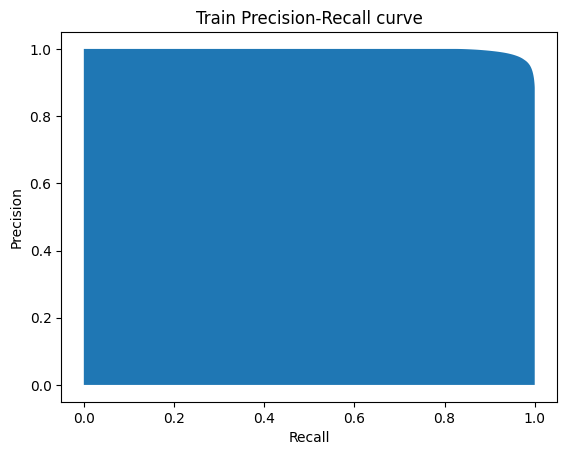

In [17]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_train, y_prob_train)
plt.fill_between(recall, precision)
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.title("Train Precision-Recall curve");

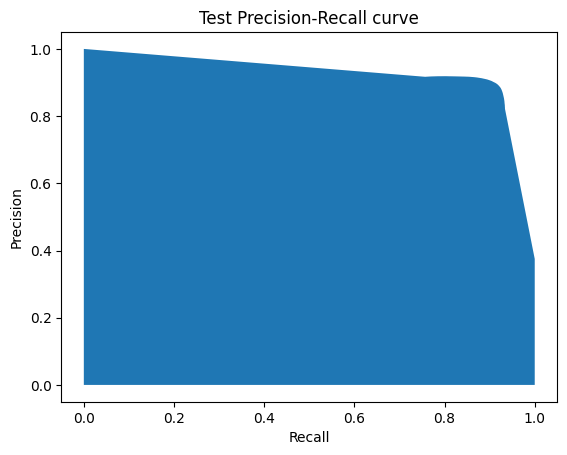

In [18]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_test)
plt.fill_between(recall, precision)
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.title("Test Precision-Recall curve");

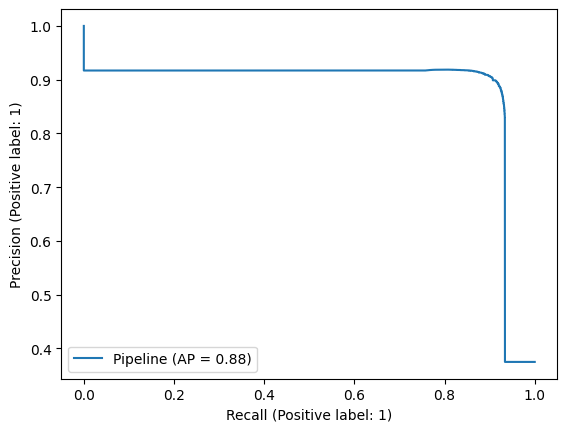

In [19]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
plt.show()

The precision-recall curve shows the tradeoff between precision and recall for different threshold. A high area under the curve represents both high recall and high precision, where high precision relates to a low false positive rate, and high recall relates to a low false negative rate. We have a high area here - both recall and precision are high.

In [20]:
average_precision_score(y_test, model.predict(X_test)).round(4)

0.8536

If we are getting more correct predictions, AP Score leads to a better PR curve and, as a result, to higher Average Precision. The higher the AP score, the better. The best possible score is 1, and the worst is 0. Here we get AP value of about 85% - Good model!

In [21]:
sample_submission = pd.read_csv("/kaggle/input/sample-submission/sample_submission.csv")
sample_submission.head()

,row_id,series_id,step,event,score
0,0,038441c925bb,100,onset,0.0
1,1,038441c925bb,105,wakeup,0.0
2,2,03d92c9f6f8a,80,onset,0.5
3,3,03d92c9f6f8a,110,wakeup,0.5
4,4,0402a003dae9,90,onset,1.0


In [22]:
test_series['score_wakeup'] = model.predict(test_series[features])[0]
test_series['score_onset'] = model.predict(test_series[features])[1]

In [23]:
sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   row_id     6 non-null      int64  
 1   series_id  6 non-null      object 
 2   step       6 non-null      int64  
 3   event      6 non-null      object 
 4   score      6 non-null      float64
dtypes: float64(1), int64(2), object(2)
memory usage: 368.0+ bytes


In [24]:
new_sample_submission = sample_submission.merge(test_series, on=['series_id', 'step'])
new_sample_submission

,row_id,series_id,step,event,score,anglez,enmo,hour,score_wakeup,score_onset
0,0,038441c925bb,100,onset,0.0,-80.118301,0.0131,15,0,0
1,1,038441c925bb,105,wakeup,0.0,-80.057098,0.0132,15,0,0
2,2,03d92c9f6f8a,80,onset,0.5,-88.216599,0.0000,12,0,0
3,3,03d92c9f6f8a,110,wakeup,0.5,-88.216599,0.0000,12,0,0
4,4,0402a003dae9,90,onset,1.0,-7.451200,0.0224,12,0,0
5,5,0402a003dae9,120,wakeup,1.0,-47.944401,0.0304,12,0,0


In [25]:
new_sample_submission.loc[new_sample_submission.event == 'onset', 'score'] = new_sample_submission.score_onset.round(0)
new_sample_submission.loc[new_sample_submission.event == 'wakeup', 'score'] = new_sample_submission.score_wakeup.round(0)

In [26]:
new_sample_submission = new_sample_submission[sample_submission.columns]
new_sample_submission

,row_id,series_id,step,event,score
0,0,038441c925bb,100,onset,0.0
1,1,038441c925bb,105,wakeup,0.0
2,2,03d92c9f6f8a,80,onset,0.0
3,3,03d92c9f6f8a,110,wakeup,0.0
4,4,0402a003dae9,90,onset,0.0
5,5,0402a003dae9,120,wakeup,0.0


In [27]:
new_sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   row_id     6 non-null      int64  
 1   series_id  6 non-null      object 
 2   step       6 non-null      int64  
 3   event      6 non-null      object 
 4   score      6 non-null      float64
dtypes: float64(1), int64(2), object(2)
memory usage: 368.0+ bytes


In [28]:
submission = sample_submission.copy()

In [29]:
submission['score'] = new_sample_submission.score
submission

,row_id,series_id,step,event,score
0,0,038441c925bb,100,onset,0.0
1,1,038441c925bb,105,wakeup,0.0
2,2,03d92c9f6f8a,80,onset,0.0
3,3,03d92c9f6f8a,110,wakeup,0.0
4,4,0402a003dae9,90,onset,0.0
5,5,0402a003dae9,120,wakeup,0.0


In [30]:
submission.to_csv('submission.csv', index=False)